In [1]:
import pandas as pd

df_train = pd.read_csv("week2 Feature Engineering/df_train_log_transformed.csv")
df_test = pd.read_csv("week2 Feature Engineering/df_test_log_transformed.csv")

print(df_train.shape)
print(df_test.shape)

(125973, 48)
(22544, 47)


In [2]:
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

print("\nTrain columns:\n", df_train.columns)
print("\nTest columns:\n", df_test.columns)

print("\nUnique labels in train:\n", df_train['label'].unique())
print("\nUnique labels in test:\n", df_test['label'].unique())

Train shape: (125973, 48)
Test shape: (22544, 47)

Train columns:
 Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level', 'attack_class',
       'is_outlier', 'log_duration', 'log_src_bytes', 'log_dst_bytes'

In [3]:
# Binary label create
df_train['binary_label'] = df_train['label'].apply(lambda x: 0 if x == 'normal' else 1)
df_test['binary_label'] = df_test['label'].apply(lambda x: 0 if x == 'normal' else 1)

print("Binary Label Distribution (Train):")
print(df_train['binary_label'].value_counts())

print("\nBinary Label Distribution (Test):")
print(df_test['binary_label'].value_counts())

Binary Label Distribution (Train):
binary_label
0    67343
1    58630
Name: count, dtype: int64

Binary Label Distribution (Test):
binary_label
1    12833
0     9711
Name: count, dtype: int64


In [4]:
X_train = df_train.drop(['label', 'binary_label'], axis=1)
y_train = df_train['binary_label']

X_test = df_test.drop(['label', 'binary_label'], axis=1)
y_test = df_test['binary_label']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (125973, 47)
y_train shape: (125973,)
X_test shape: (22544, 46)
y_test shape: (22544,)


In [5]:
# Remove attack_class (data leakage prevention)
X_train = X_train.drop('attack_class', axis=1)
X_test = X_test.drop('attack_class', axis=1)

print("attack_class removed ")

attack_class removed 


In [6]:
# One-Hot Encoding
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("After Encoding Shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

After Encoding Shapes:
X_train: (125973, 127)
X_test : (22544, 127)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Successful ")

Scaling Successful 


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train_scaled, y_train)

print("Random Forest Model Trained Successfully ")

Random Forest Model Trained Successfully 


In [9]:
y_pred = rf.predict(X_test_scaled)

print("Sample Predictions:", y_pred[:20])

Sample Predictions: [1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1]


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("\n=== MODEL PERFORMANCE ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


=== MODEL PERFORMANCE ===
Accuracy : 0.7982168204400284
Precision: 0.9691889442682374
Recall   : 0.6667186160679498
F1 Score : 0.7899912284751397

Confusion Matrix:
 [[9439  272]
 [4277 8556]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression(max_iter=2000, random_state=42)

lr.fit(X_train_scaled, y_train)

print("Logistic Regression Trained ")

Logistic Regression Trained 


In [12]:
y_pred_lr = lr.predict(X_test_scaled)

print("Sample LR Predictions:", y_pred_lr[:20])

Sample LR Predictions: [1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1]


In [13]:
print("\n=== RANDOM FOREST ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\n=== LOGISTIC REGRESSION ===")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))


=== RANDOM FOREST ===
Accuracy : 0.7982168204400284
Precision: 0.9691889442682374
Recall   : 0.6667186160679498
F1 Score : 0.7899912284751397

=== LOGISTIC REGRESSION ===
Accuracy : 0.7558995741660752
Precision: 0.9175210754158123
Recall   : 0.6276007169017377
F1 Score : 0.7453611586691963


RandomForest AUC: 0.9790438249690986
LogisticRegression AUC: 0.8761239003010266


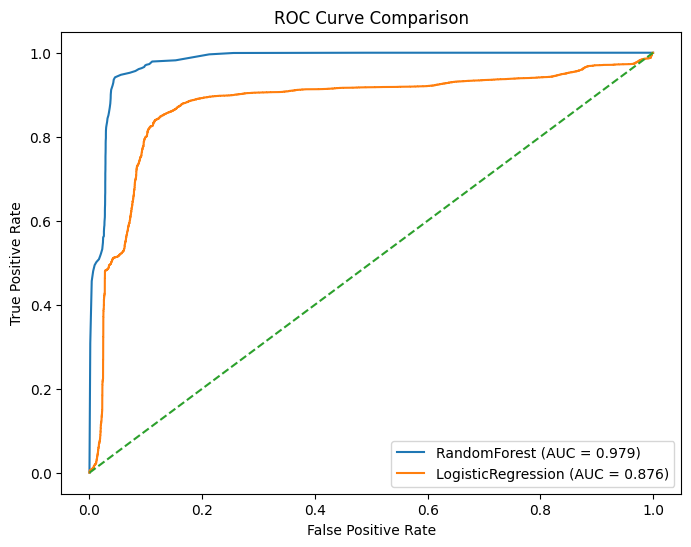

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability scores
rf_probs = rf.predict_proba(X_test_scaled)[:,1]
lr_probs = lr.predict_proba(X_test_scaled)[:,1]

# ROC values
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

# AUC
rf_auc = roc_auc_score(y_test, rf_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

print("RandomForest AUC:", rf_auc)
print("LogisticRegression AUC:", lr_auc)

# Plot
plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, label=f"RandomForest (AUC = {rf_auc:.3f})")
plt.plot(lr_fpr, lr_tpr, label=f"LogisticRegression (AUC = {lr_auc:.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [15]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
                    Feature  Importance
41            log_src_bytes    0.097864
42            log_dst_bytes    0.096300
1                 src_bytes    0.091096
25            same_srv_rate    0.069433
26            diff_srv_rate    0.058095
38         difficulty_level    0.055147
2                 dst_bytes    0.051592
125                 flag_SF    0.040941
31   dst_host_diff_srv_rate    0.040453
8                 logged_in    0.039580


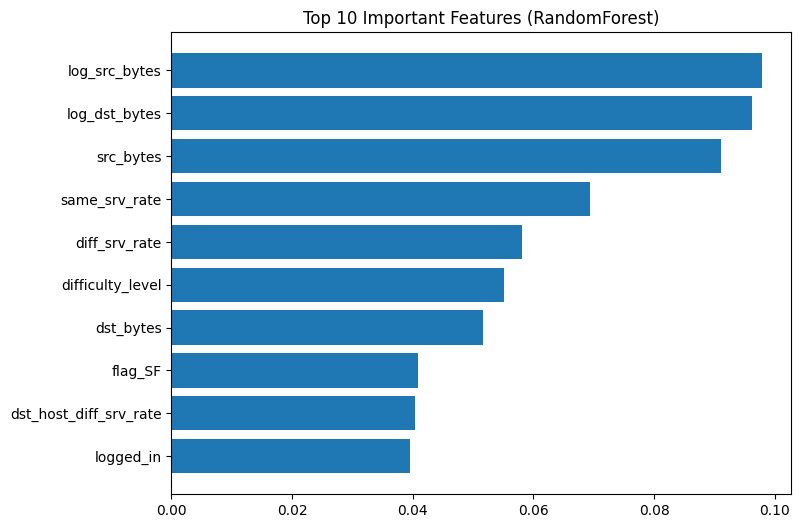

In [16]:
plt.figure(figsize=(8,6))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (RandomForest)")
plt.show()

In [17]:
print("===== PCA ANALYSIS =====")

from sklearn.decomposition import PCA
import pandas as pd

# PCA apply
pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train_scaled)

print("\nOriginal Feature Count:", X_train_scaled.shape[1])
print("Reduced Feature Count:", X_train_pca.shape[1])

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Captured:", sum(pca.explained_variance_ratio_))

===== PCA ANALYSIS =====

Original Feature Count: 127
Reduced Feature Count: 10

Explained Variance Ratio:
[0.08636697 0.0505244  0.03532374 0.02652471 0.02438102 0.0219844
 0.01981794 0.01518763 0.01391147 0.01183437]

Total Variance Captured: 0.3058566594459774


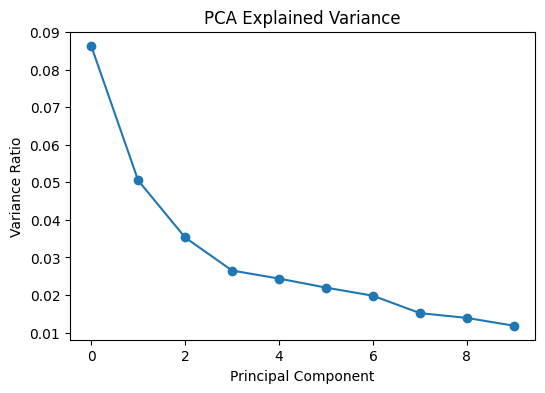

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("PCA Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.show()

===== t-SNE Visualization =====
t-SNE transformation completed
Shape: (2000, 2)


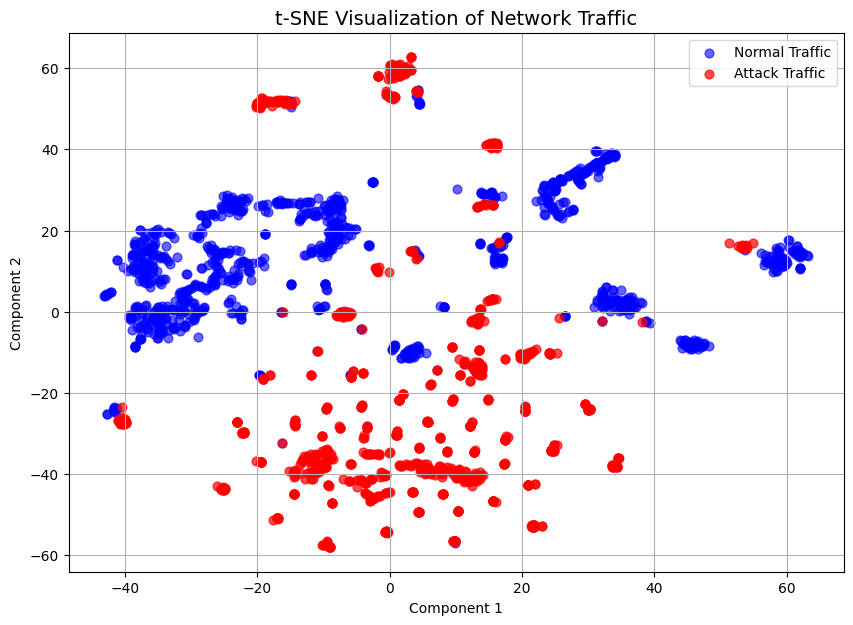

In [19]:
print("===== t-SNE Visualization =====")

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
sample_size = 2000

X_sample = X_train_scaled[:sample_size]
y_sample = y_train[:sample_size]

# t-SNE transform
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

print("t-SNE transformation completed")
print("Shape:", X_tsne.shape)

# Separate classes
normal = y_sample == 0
attack = y_sample == 1

# Plot
plt.figure(figsize=(10,7))

plt.scatter(
    X_tsne[normal,0],
    X_tsne[normal,1],
    c="blue",
    label="Normal Traffic",
    alpha=0.6,
    s=40
)

plt.scatter(
    X_tsne[attack,0],
    X_tsne[attack,1],
    c="red",
    label="Attack Traffic",
    alpha=0.7,
    s=40
)

plt.title("t-SNE Visualization of Network Traffic", fontsize=14)
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=8,          
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_scaled,y_train)

print("Best Parameters:",random_search.best_params_)
print("Best Score:",random_search.best_score_)

best_rf = random_search.best_estimator_

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best Score: 0.9996076856446959


In [21]:
y_pred_best = best_rf.predict(X_test_scaled)

from sklearn.metrics import classification_report

print("=== Tuned RandomForest Performance ===")
print(classification_report(y_test,y_pred_best))

=== Tuned RandomForest Performance ===
              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544

